# Chebyshev Policies and the Mountain Car Problem: Reinforcement Learning for Low-dimensional Control Tasks
## Chebyshev REINFORCE @ Pendulum Environment

Does good performance carry over to a more complicated problem setting?  
We utilize the Gymnasium Pendulum environment, which, again, resembles a typical low-dimensional control task but which's observation space has one more dimension.  
We use Chebyshev approximators with REINFORCE.  
  
Version 1.0  
Date: 2025-05-07    
Current version: hannes.unger@fh-salzburg.ac.at   

In [ ]:
import math
import time
import multiprocessing
import copy
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import multiprocessing as mp
from utils import parallel
from pickleshare import PickleShareDB
from algorithms import polynomial_agents
from IPython import display

db = PickleShareDB('./picklesharedb')
environment_name = "Pendulum-v1"
rlzoo_agents_directory = "rlzoo-pendulum-trained-agents"

%load_ext autoreload
%autoreload 2

In [2]:
def moving_average(arr, window_size):
    return np.convolve(arr, np.ones(window_size)/window_size, mode='valid')

In [3]:
def run_chebyshev_model(coeffs, env_name=environment_name, degree=3, normalize_observations=True, start_loc=[0.0, 0.0], render=False):
    if render:
        env = gym.make(env_name, render_mode='rgb_array')
    else: 
        env = gym.make(env_name)
    mrp = polynomial_agents.TrainableContinuousMRPWrapper(env, basis='chebyshev', degree=degree,
                                                                    normalize_observations=normalize_observations,
                                                                    initial_sigma=0.25,
                                                                    mu_coeffs=coeffs)  

    if start_loc:      
        obs = mrp.reset(options={'x_init': start_loc[0], 'y_init': start_loc[1], 'render_mode': None})[0]
    else:
        obs = mrp.reset()[0]

    print(".", end="")

    episode_reward = 0.0
    observations = []
    episode_len = 0

    # Run actions from trained policy
    while True:
        if render:
            img = env.render() # Workaround for render mode "human" crashing kernel: https://github.com/openai/gym/issues/3031
            plt.imshow(img)
            display.clear_output(wait=True)
            display.display(plt.gcf())
        observations.append(obs)
        obs, reward, terminated, truncated, info, action, _ = mrp.step(obs)
        episode_reward += reward
        episode_len += 1
        if terminated or truncated:
            print(f"Episode Reward: {episode_reward:.2f} after {episode_len} steps")
            break

    print("#", end="")

    return episode_reward, observations

### Play around with environment

In [4]:
env = gym.make(environment_name) 
env.reset() # Resets the environment to the initial state and returns that state

(array([ 0.41493714, -0.90985006, -0.0495939 ], dtype=float32), {})

In [5]:
# Continuous action (applied force) in the range [-1, 1], with negative values pushing left and positive ones right
env.action_space

Box(-2.0, 2.0, (1,), float32)

In [6]:
# Random action
env.action_space.sample()

array([-0.13888288], dtype=float32)

In [7]:
# ?
env.observation_space

Box([-1. -1. -8.], [1. 1. 8.], (3,), float32)

In [8]:
# Random observation, gives state [pos, vel]
env.observation_space.sample()

array([0.51983297, 0.08698583, 7.655782  ], dtype=float32)

In [9]:
# Random action
env.action_space.sample()

array([0.03004618], dtype=float32)

In [10]:
# Random step with random action, returns (next_state, reward, terminated, truncated, info)
env.step(env.action_space.sample())

(array([ 0.37440503, -0.9272653 , -0.8823731 ], dtype=float32),
 -1.3075232751481107,
 False,
 False,
 {})

### Test normalization

In [11]:
test_dim_x = np.linspace(-8, 8, 16)
test_dim_y = [x for x in test_dim_x]

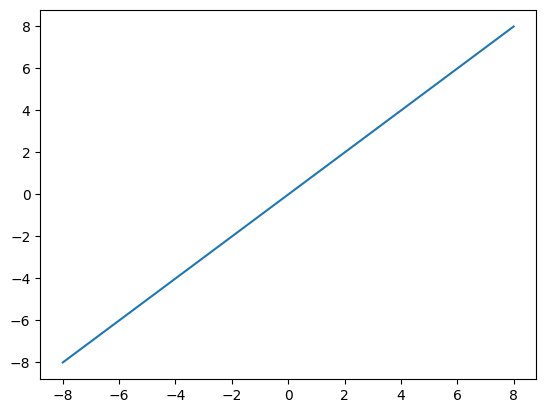

In [12]:
plt.plot(test_dim_x, test_dim_y)

In [13]:
def normalize(value, max_value, min_value, new_max=1.0, new_min=-1.0):
    """
    Normalize a single value to a specified range [new_min, new_max].

    Args:
    - value: The value to be normalized.
    - min_value: The minimum value of the original range.
    - max_value: The maximum value of the original range.
    - new_min: The minimum value of the new range.
    - new_max: The maximum value of the new range.

    Returns:
    - The normalized value.
    """
    return ((value - min_value) / (max_value - min_value)) * (new_min - new_max) + new_max  # [1.2 , 0.07] -> [-1.0, -1.0]
    #return ((value - min_value) / (max_value - min_value)) * (new_max - new_min) + new_min   # [1.2 , 0.07] -> [1.0, 1.0]

def unnormalize(value, max_value, min_value, new_max=1.0, new_min=-1.0):
    """
    Unnormalize a single value given a specified range [new_min, new_max].

    Args:
    - value: The value to be unnormalized.
    - min_value: The minimum value of the original range.
    - max_value: The maximum value of the original range.
    - new_min: The minimum value of the new range, the value was normalized to.
    - new_max: The maximum value of the new range, the value was normalized to.

    Returns:
    - The unnormalized value.
    """
    return (new_min*min_value - new_max*max_value + value *(max_value - min_value))/(new_min-new_max) # [1.0, 1.0] -> [-1.2 , -0.07]
    #return (new_min*max_value - new_max*min_value + value *(min_value - max_value))/(new_min-new_max) # [1.0, 1.0] -> [1.2 , 0.07]

In [14]:
max_value = max(test_dim_x)
min_value = min(test_dim_x)
print(f'[{max_value}, {min_value}]')

test_dim_x_normalized = [normalize(x, max_value=max_value, min_value=min_value) for x in test_dim_x]
print(f'{test_dim_x_normalized}')

[8.0, -8.0]
[1.0, 0.8666666666666667, 0.7333333333333334, 0.6, 0.4666666666666667, 0.33333333333333337, 0.19999999999999996, 0.06666666666666665, -0.06666666666666665, -0.19999999999999996, -0.33333333333333326, -0.46666666666666656, -0.6000000000000001, -0.7333333333333334, -0.8666666666666667, -1.0]


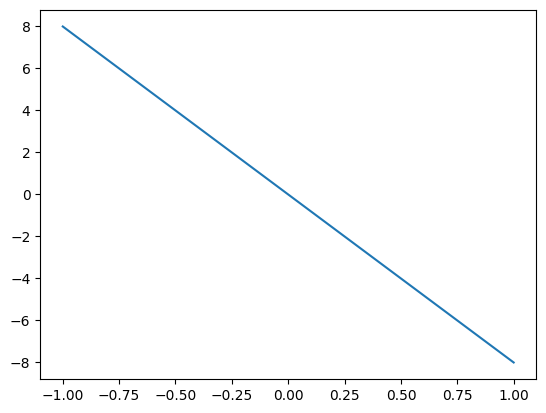

In [15]:
plt.plot(test_dim_x_normalized, test_dim_y)

The current implementation flips the sign of values for the axis.  

[8.0, -8.0]
[-8.0, -6.933333333333334, -5.866666666666667, -4.8, -3.7333333333333334, -2.666666666666667, -1.5999999999999996, -0.5333333333333332, 0.5333333333333332, 1.5999999999999996, 2.666666666666666, 3.7333333333333325, 4.800000000000001, 5.866666666666667, 6.933333333333334, 8.0]


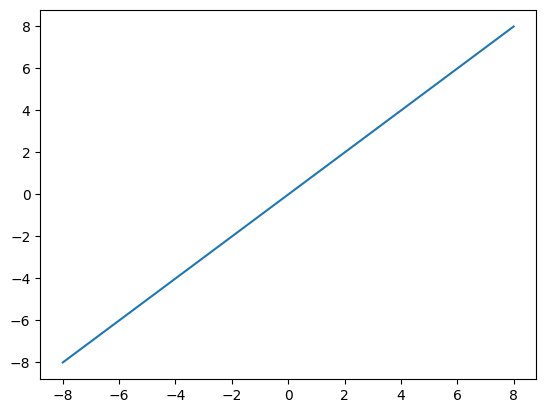

In [16]:
max_value = max(test_dim_x)
min_value = min(test_dim_x)
print(f'[{max_value}, {min_value}]')

test_dim_x_denormalized = [unnormalize(x, max_value=max_value, min_value=min_value) for x in test_dim_x_normalized]
print(f'{test_dim_x_denormalized}')
plt.plot(test_dim_x_denormalized, test_dim_y)

The unnormalize function restores the original data and "flips the axis back".    
The function was not used in previous experiments.  
Functions requiring denormalization like "plot_heatmap" in "polynomial_agents.py" queried the agent with normalized states given correct denormalized axis instead.  
Lets fix the normalization function. To stay compatible, we introduce the "flip" parameter, which is True by default.   

In [17]:
def normalize(value, max_value, min_value, new_max=1.0, new_min=-1.0, flip=True):
    """
    Normalize a single value to a specified range [new_min, new_max].

    Args:
    - value: The value to be normalized.
    - min_value: The minimum value of the original range.
    - max_value: The maximum value of the original range.
    - new_min: The minimum value of the new range.
    - new_max: The maximum value of the new range.

    Returns:
    - The normalized value.
    """
    if flip:
        return ((value - min_value) / (max_value - min_value)) * (new_min - new_max) + new_max  
    else:
        return ((value - min_value) / (max_value - min_value)) * (new_max - new_min) + new_min 


def unnormalize(value, max_value, min_value, new_max=1.0, new_min=-1.0, flip=True):
    """
    Unnormalize a single value given a specified range [new_min, new_max].

    Args:
    - value: The value to be unnormalized.
    - min_value: The minimum value of the original range.
    - max_value: The maximum value of the original range.
    - new_min: The minimum value of the new range, the value was normalized to.
    - new_max: The maximum value of the new range, the value was normalized to.

    Returns:
    - The unnormalized value.
    """
    if flip:
        return (value-new_max)/(new_min-new_max)*(max_value-min_value)+min_value
    else:
        return (value-new_min)/(new_max-new_min)*(max_value-min_value)+min_value

[8.0, -8.0]
[-1.0, -0.8666666666666667, -0.7333333333333334, -0.6, -0.4666666666666667, -0.33333333333333337, -0.19999999999999996, -0.06666666666666665, 0.06666666666666665, 0.19999999999999996, 0.33333333333333326, 0.46666666666666656, 0.6000000000000001, 0.7333333333333334, 0.8666666666666667, 1.0]


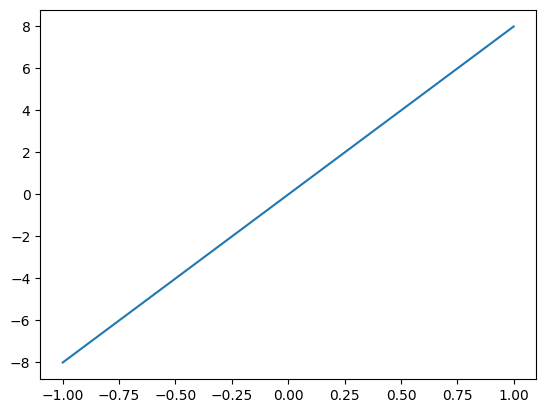

In [26]:
max_value = max(test_dim_x)
min_value = min(test_dim_x)
print(f'[{max_value}, {min_value}]')

test_dim_x_normalized = [normalize(x, max_value=max_value, min_value=min_value, flip=False) for x in test_dim_x]
print(f'{test_dim_x_normalized}')
plt.plot(test_dim_x_normalized, test_dim_y)

[8.0, -8.0]
[-8.0, -6.933333333333334, -5.866666666666667, -4.8, -3.7333333333333334, -2.666666666666667, -1.5999999999999996, -0.5333333333333332, 0.5333333333333332, 1.5999999999999996, 2.666666666666666, 3.7333333333333325, 4.800000000000001, 5.866666666666667, 6.933333333333334, 8.0]


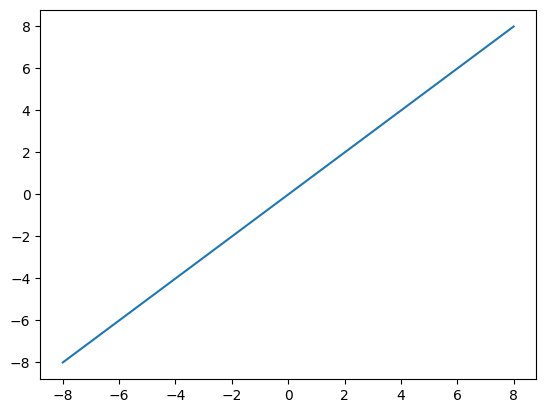

In [29]:
max_value = max(test_dim_x)
min_value = min(test_dim_x)
print(f'[{max_value}, {min_value}]')

test_dim_x_denormalized = [unnormalize(x, max_value=max_value, min_value=min_value, flip=False) for x in test_dim_x_normalized]
print(f'{test_dim_x_denormalized}')
plt.plot(test_dim_x_denormalized, test_dim_y)

Works as expected now.  

### Reset condition

x_init is used for cos(theta) init and y_init for sin(theta) init.  
We can only pass one parameter for each, which is then used for both low and high bound,  
so we cannot deterministically initialize at positions other than 0.0.  

In [45]:
#pendulum.py:  
# if options is None:  
#             high = np.array([DEFAULT_X, DEFAULT_Y])  
#         else:  
#             # Note that if you use custom reset bounds, it may lead to out-of-bound  
#             # state/observations.  
#             x = options.get("x_init") if "x_init" in options else DEFAULT_X  
#             y = options.get("y_init") if "y_init" in options else DEFAULT_Y  
#             x = utils.verify_number_and_cast(x)  
#             y = utils.verify_number_and_cast(y)  
#             high = np.array([x, y])   
#         low = -high  # We enforce symmetric limits.  
#         self.state = self.np_random.uniform(low=low, high=high)  

theta = 0.0


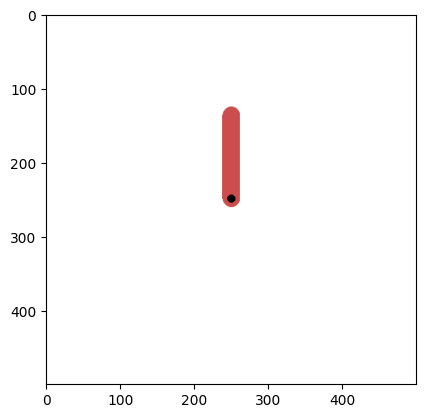

In [80]:
env = gym.make(environment_name, render_mode='rgb_array') 
obs = env.reset(options={'x_init': 0.0, 'y_init': 0.0})[0]
img = env.render() # Workaround for render mode "human" crashing kernel: https://github.com/openai/gym/issues/3031
plt.imshow(img)
display.clear_output(wait=True)
print(f'theta = {math.atan2(obs[1], obs[0])}')

theta = 1.8398213464320277


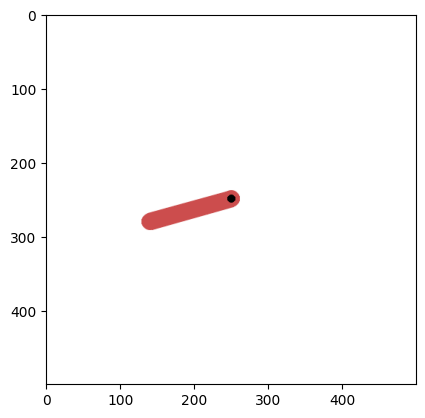

In [85]:
obs = env.reset(options={'x_init': np.pi, 'y_init': np.pi})[0]
img = env.render() # Workaround for render mode "human" crashing kernel: https://github.com/openai/gym/issues/3031
plt.imshow(img)
display.clear_output(wait=True)
print(f'theta = {math.atan2(obs[1], obs[0])}')

In [17]:
# # Run some random actions
# for i in range(200):
#     env.render()
#     obs, reward, terminated, truncated, info = env.step(env.action_space.sample())
#     if terminated:
#         s = env.reset()

## Degree 3, Vanilla REINFORCE

Gymnasium offers ObservationWrappers: [https://gymnasium.farama.org/api/wrappers/observation_wrappers/](https://gymnasium.farama.org/api/wrappers/observation_wrappers/)

In [ ]:
alpha=0.0003
alpha_mu=0.0003
alpha_sigma=0.00003
episodes=100
discount=0.9 # discount=1.0 diverges for sigma approximator
initial_sigma=0.25 # The higher, the more initial exploration

In [ ]:
env = gym.make(environment_name) 
#env = gym.make("MountainCarContinuous-v0") 
reinforce_trainable_mrp_max_deg3_norm = polynomial_agents.TrainableContinuousMRPWrapper(env, basis='chebyshev', degree=3, normalize_observations=True, initial_sigma=initial_sigma)
reinforce_trainable_mrp_max_deg3_norm.reset()[0]

In [ ]:
reinforce_trainable_mrp_max_deg3_norm.env.observation_space.low

In [ ]:
reinforce_trainable_mrp_max_deg3_norm.env.observation_space.high

In [ ]:
kwargs = {'env_name': environment_name, 'alpha_mu': alpha_mu, 'alpha_sigma': alpha_sigma, 'episodes': episodes, 'discount': discount, 'initial_sigma': initial_sigma, 'method': 'reinforce', 'normalize_observations': True}

n_runs = 5
args = [kwargs for i in range(n_runs)]

with mp.Pool(processes=n_runs) as pool:
    reinforce_trainable_mrp_max_deg3_norm_results = pool.map(parallel.job_reinforce_train, args)

# Permanently store results
db['reinforce_trainable_mrp_max_deg3_norm_results'] = reinforce_trainable_mrp_max_deg3_norm_results

In [83]:
env = gym.make(environment_name, render_mode="rgb_array") 

reinforce_trainable_mrp_max_deg3_norm_results = db['reinforce_trainable_mrp_max_deg3_norm_results']

best_index_reinforce = max(enumerate(reinforce_trainable_mrp_max_deg3_norm_results), key=lambda x: x[1][0])[0]
reinforce_trainable_mrp_max_deg3_norm = polynomial_agents.TrainableContinuousMRPWrapper(env, basis='chebyshev', degree=3, normalize_observations=True, initial_sigma=initial_sigma, mu_coeffs=reinforce_trainable_mrp_max_deg3_norm_results[best_index_reinforce][-1], sigma_coeffs=reinforce_trainable_mrp_max_deg3_norm_results[best_index_reinforce][-2])
obs = reinforce_trainable_mrp_max_deg3_norm.reset()[0]

Text(0.5, 1.0, 'Cumulated reward over episodes, best result out of 5 runs')

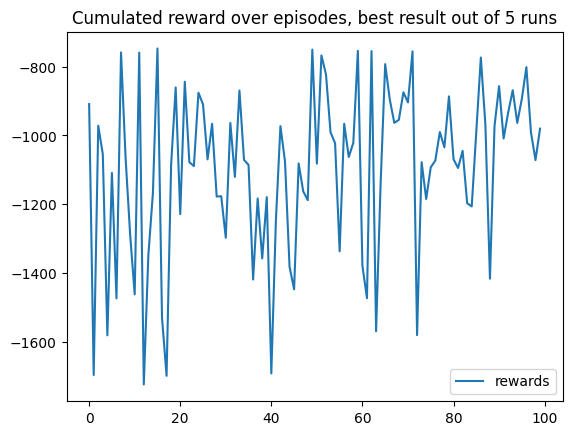

In [84]:
plt.plot(reinforce_trainable_mrp_max_deg3_norm_results[best_index_reinforce][1], label='rewards')
plt.legend(loc='best')
plt.title(f'Cumulated reward over episodes, best result out of {n_runs} runs')

### Try another training run with 1000 episodes and non- autodiff REINFORCE

In [39]:
alpha=0.0003
alpha_mu=0.0003
alpha_sigma=0.00003
episodes=1000
discount=0.9 
initial_sigma=0.25 # The higher, the more initial exploration

In [ ]:
kwargs = {'env_name': environment_name, 'alpha_mu': alpha_mu, 'alpha_sigma': alpha_sigma, 'episodes': episodes, 'discount': discount, 'initial_sigma': initial_sigma, 'method': 'reinforce', 'normalize_observations': True}

n_runs = 5
args = [kwargs for i in range(n_runs)]

with mp.Pool(processes=n_runs) as pool:
    reinforce_trainable_mrp_max_deg3_norm_results_1000 = pool.map(parallel.job_reinforce_train, args)

# Permanently store results
db['reinforce_trainable_mrp_max_deg3_norm_results_1000'] = reinforce_trainable_mrp_max_deg3_norm_results_1000

Note: The above cell took 334 minutes to execute.

Text(0.5, 1.0, 'Cumulated reward over episodes, best result out of 5 runs (index: 4)')

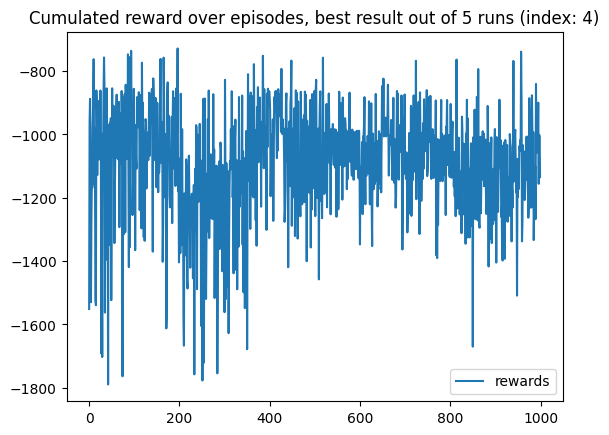

In [87]:
reinforce_trainable_mrp_max_deg3_norm_results_1000 = db['reinforce_trainable_mrp_max_deg3_norm_results_1000']
best_index_reinforce_1000 = max(range(len(reinforce_trainable_mrp_max_deg3_norm_results_1000)), key=lambda i: reinforce_trainable_mrp_max_deg3_norm_results_1000[i][0])
plt.plot(reinforce_trainable_mrp_max_deg3_norm_results_1000[best_index_reinforce_1000][1], label='rewards')
plt.legend(loc='best')
plt.title(f'Cumulated reward over episodes, best result out of {n_runs} runs (index: {best_index_reinforce_1000})')

In [ ]:
kwargs = {'env_name': environment_name, 'episodes': 50}
reinforce_trainable_mrp_max_deg3_norm_results_1000 = db['reinforce_trainable_mrp_max_deg3_norm_results_1000']

n_runs = len(reinforce_trainable_mrp_max_deg3_norm_results_1000)
args = []

for r in reinforce_trainable_mrp_max_deg3_norm_results_1000:
    arg = copy.deepcopy(kwargs)
    arg['mu_coeffs'] = r[-1]
    args.append(arg)

with mp.Pool(processes=n_runs) as pool:
    reinforce_trainable_mrp_max_deg3_norm_1000_evaluation = pool.map(parallel.job_evaluate, args)

# Permanently store results
db['reinforce_trainable_mrp_max_deg3_norm_1000_evaluation'] = reinforce_trainable_mrp_max_deg3_norm_1000_evaluation

Note: The above cell took 4 minutes to execute.

In [ ]:
reinforce_trainable_mrp_max_deg3_norm_1000_evaluation = db['reinforce_trainable_mrp_max_deg3_norm_1000_evaluation']
best_index_reinforce_1000_eval = max(range(len(reinforce_trainable_mrp_max_deg3_norm_1000_evaluation)), key=lambda i: sum(reinforce_trainable_mrp_max_deg3_norm_1000_evaluation[i]))
best_index_reinforce_1000_eval

Text(0.5, 1.0, 'Cumulated reward over episodes, best result out of 5 runs (index: 2)')

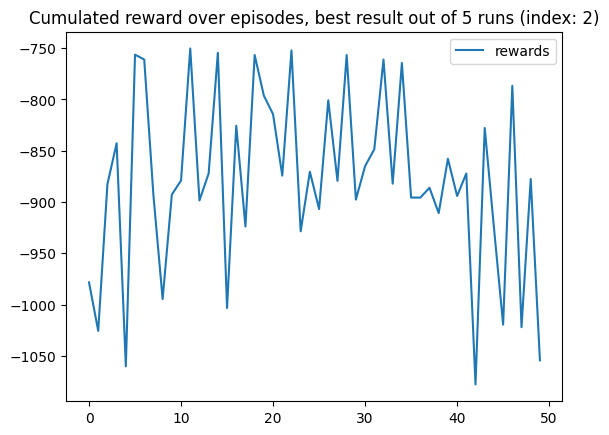

In [90]:
plt.plot(reinforce_trainable_mrp_max_deg3_norm_1000_evaluation[best_index_reinforce_1000_eval], label='rewards')
plt.legend(loc='best')
plt.title(f'Cumulated reward over episodes, best result out of {n_runs} runs (index: {best_index_reinforce_1000_eval})')

In [92]:
db['chebyshev_reinforce_deg3_coeffs']  = reinforce_trainable_mrp_max_deg3_norm_results_1000[best_index_reinforce_1000_eval][-1]

In [98]:
chebyshev_coeffs = db['chebyshev_reinforce_deg3_coeffs']
chebyshev_episode_reward, rewards = run_chebyshev_model(chebyshev_coeffs, degree=3, start_loc=[0.0, 0.0], render=False)
len(rewards)

.Episode Reward: -755.49
#

200

### Increase learning rate

In [ ]:
alpha_mu=0.003
alpha_sigma=0.0003
episodes=1000
discount=0.9 
initial_sigma=0.0 # sigma = exp(initial_sigma) = 1.0

In [ ]:
kwargs = {'env_name': environment_name, 'alpha_mu': alpha_mu, 'alpha_sigma': alpha_sigma, 'episodes': episodes, 'discount': discount, 'initial_sigma': initial_sigma, 'method': 'reinforce', 'normalize_observations': True}

n_runs = 10
args = [kwargs for i in range(n_runs)]

with mp.Pool(processes=n_runs) as pool:
    reinforce_trainable_mrp_max_deg3_norm_results_1000_2 = pool.map(parallel.job_reinforce_train, args)

# Permanently store results
db['reinforce_trainable_mrp_max_deg3_norm_results_1000_2'] = reinforce_trainable_mrp_max_deg3_norm_results_1000_2

In [ ]:
kwargs = {'env_name': environment_name, 'episodes': 50}
reinforce_trainable_mrp_max_deg3_norm_results_1000_2 = db['reinforce_trainable_mrp_max_deg3_norm_results_1000_2']

n_runs = len(reinforce_trainable_mrp_max_deg3_norm_results_1000_2)
args = []

for r in reinforce_trainable_mrp_max_deg3_norm_results_1000_2:
    arg = copy.deepcopy(kwargs)
    arg['mu_coeffs'] = r[-1]
    args.append(arg)

with mp.Pool(processes=n_runs) as pool:
    reinforce_trainable_mrp_max_deg3_norm_1000_evaluation_2 = pool.map(parallel.job_evaluate, args)

# Permanently store results
db['reinforce_trainable_mrp_max_deg3_norm_1000_evaluation_2'] = reinforce_trainable_mrp_max_deg3_norm_1000_evaluation_2

.....#####

Text(0.5, 1.0, 'Cumulated reward over episodes, best result out of 5 runs (index: 3)')

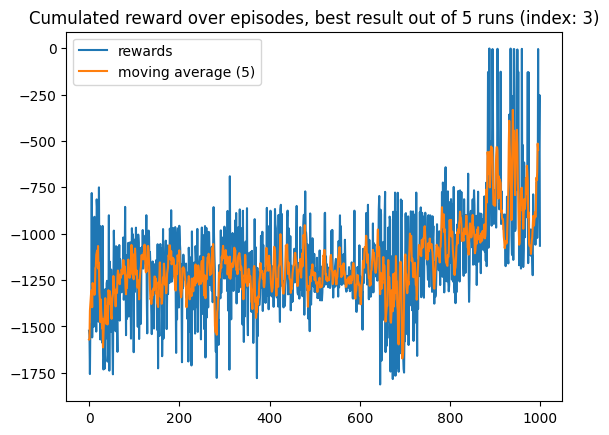

In [ ]:
reinforce_trainable_mrp_max_deg3_norm_10000_evaluation = db['reinforce_trainable_mrp_max_deg3_norm_results_1000_2']

window_size=5
reinforce_trainable_mrp_max_deg3_norm_results_1000_2_moving_average_results = moving_average(reinforce_trainable_mrp_max_deg3_norm_results_1000_2[best_index_reinforce_1000_eval][1], window_size=window_size)

plt.plot(reinforce_trainable_mrp_max_deg3_norm_results_1000_2[best_index_reinforce_1000_eval][1], label='rewards')
plt.plot(reinforce_trainable_mrp_max_deg3_norm_results_1000_2_moving_average_results, label=f'moving average ({window_size})')
plt.legend(loc='best')
plt.title(f'Cumulated reward over episodes, best result out of {n_runs} runs (index: {best_index_reinforce_1000_eval})')

In [117]:
reinforce_trainable_mrp_max_deg3_norm_results_1000_2 = db['reinforce_trainable_mrp_max_deg3_norm_results_1000_2']
db['chebyshev_reinforce_deg3_coeffs_2']  = reinforce_trainable_mrp_max_deg3_norm_results_1000_2[best_index_reinforce_1000_eval][-1]

In [118]:
chebyshev_coeffs = db['chebyshev_reinforce_deg3_coeffs_2']
chebyshev_episode_reward, rewards = run_chebyshev_model(chebyshev_coeffs, degree=3, start_loc=[0.0, 0.0], render=False)

.Episode Reward: -1.96
#

These hyperparameters seem to enable learning!  

## Training with AdamW

Since our Mountain Car experiments show performance with this optimizer is good, we repeat experiments with found hyperparameters and this optimizer.  

In [13]:
alpha_mu=0.003
alpha_sigma=0.0003
episodes=1500
discount=0.9 
initial_sigma=0.25 
optimizer='adamw'

In [ ]:
kwargs = {'env_name': environment_name, 'alpha_mu': alpha_mu, 'alpha_sigma': alpha_sigma, 'episodes': episodes, 'discount': discount, 'initial_sigma': initial_sigma, 'method': 'reinforce_autodiff', 'normalize_observations': True, 'mu_optimizer': optimizer, 'sigma_optimizer': optimizer}

n_runs = 20
args = [kwargs for i in range(n_runs)]

with mp.Pool(processes=multiprocessing.cpu_count()) as pool:
    reinforce_trainable_mrp_max_deg3_adamw_results_1500 = pool.map(parallel.job_reinforce_train, args)

# Permanently store results
db['reinforce_trainable_mrp_max_deg3_adamw_results_1500'] = reinforce_trainable_mrp_max_deg3_adamw_results_1500

In [ ]:
kwargs = {'env_name': environment_name, 'episodes': 50}
reinforce_trainable_mrp_max_deg3_adamw_results_1500 = db['reinforce_trainable_mrp_max_deg3_adamw_results_1500']

n_runs = len(reinforce_trainable_mrp_max_deg3_adamw_results_1500)
args = []

for r in reinforce_trainable_mrp_max_deg3_adamw_results_1500:
    arg = copy.deepcopy(kwargs)
    try:
        arg['mu_coeffs'] = r[-1]
    except:
        arg['mu_coeffs'] = None
    args.append(arg)

with mp.Pool(processes=n_runs) as pool:
    reinforce_trainable_mrp_max_deg3_adamw_evaluation_1500 = pool.map(parallel.job_evaluate, args)

# Permanently store results
db['reinforce_trainable_mrp_max_deg3_adamw_evaluation_1500'] = reinforce_trainable_mrp_max_deg3_adamw_evaluation_1500

Text(0.5, 1.0, 'Cumulated reward over episodes, best result out of 20 runs (index: 4)')

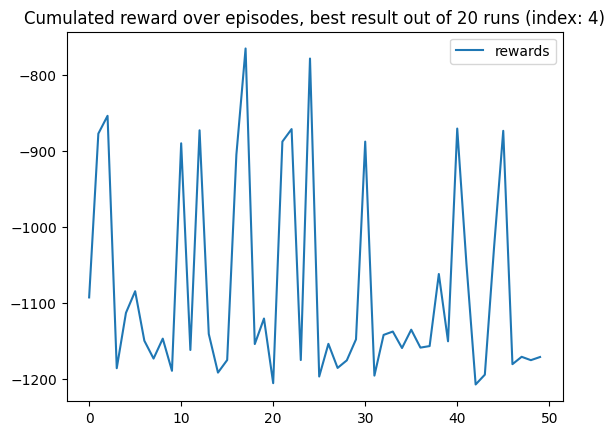

In [15]:
reinforce_trainable_mrp_max_deg3_adamw_evaluation_1500 = db['reinforce_trainable_mrp_max_deg3_adamw_evaluation_1500']

max_reward = -np.inf
max_index = 0

for i, r in enumerate(reinforce_trainable_mrp_max_deg3_adamw_evaluation_1500):
    reward = np.mean(r)
    if reward > max_reward:
        max_reward = reward
        max_index = i

best_index_reinforce_eval = max_index
plt.plot(reinforce_trainable_mrp_max_deg3_adamw_evaluation_1500[best_index_reinforce_eval], label='rewards')
plt.legend(loc='best')
plt.title(f'Cumulated reward over episodes, best result out of {n_runs} runs (index: {best_index_reinforce_eval})')

Text(0.5, 1.0, 'Cumulated reward over episodes, best result out of 20 runs (index: 4)')

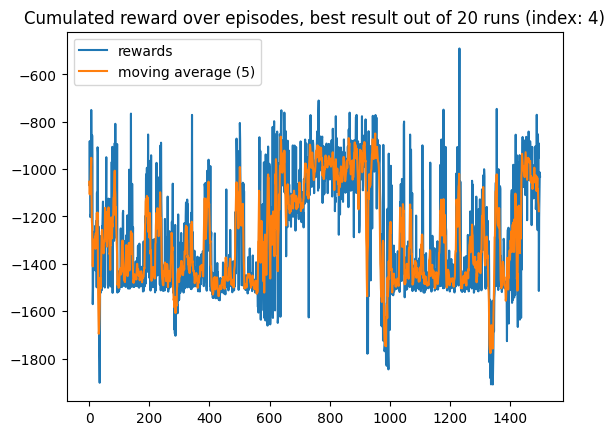

In [16]:
reinforce_trainable_mrp_max_deg3_adamw_results_1500 = db['reinforce_trainable_mrp_max_deg3_adamw_results_1500']

window_size=5
reinforce_trainable_mrp_max_deg3_norm_adamw_moving_average_results = moving_average(reinforce_trainable_mrp_max_deg3_adamw_results_1500[best_index_reinforce_eval][1], window_size=window_size)

plt.plot(reinforce_trainable_mrp_max_deg3_adamw_results_1500[best_index_reinforce_eval][1], label='rewards')
plt.plot(reinforce_trainable_mrp_max_deg3_norm_adamw_moving_average_results, label=f'moving average ({window_size})')
plt.legend(loc='best')
plt.title(f'Cumulated reward over episodes, best result out of {n_runs} runs (index: {best_index_reinforce_eval})')

In [17]:
reinforce_trainable_mrp_max_deg3_adamw_results_1500 = db['reinforce_trainable_mrp_max_deg3_adamw_results_1500']
db['chebyshev_reinforce_adamw_coeffs']  = reinforce_trainable_mrp_max_deg3_adamw_results_1500[best_index_reinforce_eval][-1]

In [ ]:
reinforce_trainable_mrp_max_deg3_adamw_results_1500 = db['reinforce_trainable_mrp_max_deg3_adamw_results_1500']

r = []
for i in range(50):
    chebyshev_episode_reward, rewards = run_chebyshev_model(reinforce_trainable_mrp_max_deg3_adamw_results_1500[best_index_reinforce_eval][-1], degree=3, start_loc=None, render=False)
    r.append(chebyshev_episode_reward)
db['reinforce_trainable_mrp_max_deg3_adamw_results_1000_best_eval_result'] = r

In [ ]:
reinforce_trainable_mrp_max_deg3_norm_results_1000_2 = db['reinforce_trainable_mrp_max_deg3_norm_results_1000_2']

r = []
for i in range(50):
    chebyshev_episode_reward, obs = run_chebyshev_model(reinforce_trainable_mrp_max_deg3_norm_results_1000_2[3][-1], degree=3, start_loc=None, render=False)
    r.append(chebyshev_episode_reward)
db['reinforce_trainable_mrp_max_deg3_norm_results_1000_best_eval_result'] = r

### Continue training on REINFORCE policy

Training with AdamW does not perform as well as training with vanilla REINFORCE. 
Trying to train the best REINFORCE agent for another 1000 episodes.  
Lowering learning rate again, as we want to prevent REINFORCE from drifting away too far from the "good" policy.  

In [16]:
reinforce_trainable_mrp_max_deg3_norm_results_1000_2 = db['reinforce_trainable_mrp_max_deg3_norm_results_1000_2']

alpha_mu=0.0003
alpha_sigma=0.00003
episodes=100
discount=0.9 
initial_sigma=0.25 
mu_coeffs = copy.deepcopy(reinforce_trainable_mrp_max_deg3_norm_results_1000_2[3][-1])
sigma_coeffs = copy.deepcopy(reinforce_trainable_mrp_max_deg3_norm_results_1000_2[3][-2])

kwargs = {'env_name': environment_name, 'alpha_mu': alpha_mu, 'alpha_sigma': alpha_sigma, 'episodes': episodes, 'discount': discount, 'initial_sigma': initial_sigma, 'method': 'reinforce', 'normalize_observations': True, 'mu_coeffs': mu_coeffs, 'sigma_coeffs': sigma_coeffs}

In [ ]:
start = time.time()

reinforce_trainable_mrp_max_deg3_norm_results_2000 = parallel.job_reinforce_train(kwargs)
db['reinforce_trainable_mrp_max_deg3_norm_results_2000'] = reinforce_trainable_mrp_max_deg3_norm_results_2000

end = time.time()
execution_time = (end - start)/60
print(f"Execution took {execution_time:.2f} minutes")

Text(0.5, 1.0, '')

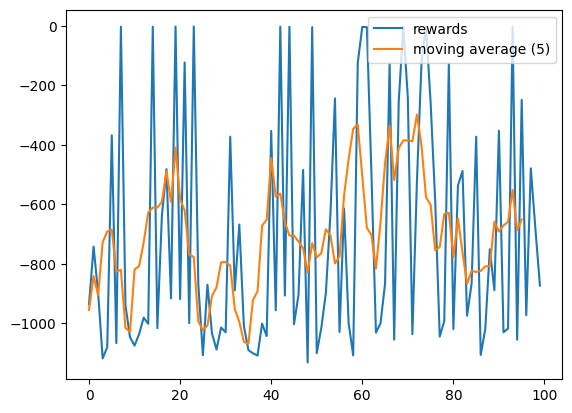

In [19]:
reinforce_trainable_mrp_max_deg3_norm_results_2000 = db['reinforce_trainable_mrp_max_deg3_norm_results_2000']

window_size=5
moving_average_results = moving_average(reinforce_trainable_mrp_max_deg3_norm_results_2000[1], window_size=window_size)

plt.plot(reinforce_trainable_mrp_max_deg3_norm_results_2000[1], label='rewards')
plt.plot(moving_average_results, label=f'moving average ({window_size})')
plt.legend(loc='best')
plt.title(f'')

In [ ]:
reinforce_trainable_mrp_max_deg3_norm_results_2000 = db['reinforce_trainable_mrp_max_deg3_norm_results_2000']

r = []
for i in range(50):
    chebyshev_episode_reward, obs = run_chebyshev_model(reinforce_trainable_mrp_max_deg3_norm_results_2000[-1], degree=3, start_loc=None, render=False)
    r.append(chebyshev_episode_reward)
db['reinforce_trainable_mrp_max_deg3_norm_results_2000_best_eval_result'] = r

Training works and continues to improve on the previous policy!  
Lets now continue training a number of policies with lowered learning rate and a number of policies with increased learning rate for more episodes.

In [14]:
reinforce_trainable_mrp_max_deg3_norm_results_1000_2 = db['reinforce_trainable_mrp_max_deg3_norm_results_1000_2']

alpha_mu_1=0.003
alpha_sigma_1=0.0003
alpha_mu_2=0.0003
alpha_sigma_2=0.00003
episodes=3000
discount=0.9 
initial_sigma=0.25 
mu_coeffs = copy.deepcopy(reinforce_trainable_mrp_max_deg3_norm_results_1000_2[3][-1])
sigma_coeffs = copy.deepcopy(reinforce_trainable_mrp_max_deg3_norm_results_1000_2[3][-2])

kwargs_1 = {'env_name': environment_name, 'alpha_mu': alpha_mu_1, 'alpha_sigma': alpha_sigma_1, 'episodes': episodes, 'discount': discount, 'initial_sigma': initial_sigma, 'method': 'reinforce', 'normalize_observations': True, 'mu_coeffs': mu_coeffs, 'sigma_coeffs': sigma_coeffs}
kwargs_2 = {'env_name': environment_name, 'alpha_mu': alpha_mu_2, 'alpha_sigma': alpha_sigma_2, 'episodes': episodes, 'discount': discount, 'initial_sigma': initial_sigma, 'method': 'reinforce', 'normalize_observations': True, 'mu_coeffs': mu_coeffs, 'sigma_coeffs': sigma_coeffs}

n_runs = 20
args = [copy.deepcopy(kwargs_1) for i in range(10)]
args.extend([copy.deepcopy(kwargs_2) for i in range(10)])

In [ ]:
with mp.Pool(processes=mp.cpu_count()) as pool:
    training_results = pool.map(parallel.job_reinforce_train, args)

# Permanently store results
db['reinforce_trainable_mrp_max_deg3_norm_results_5000'] = training_results

In [ ]:
kwargs = {'env_name': environment_name, 'episodes': 50}
training_results = db['reinforce_trainable_mrp_max_deg3_norm_results_5000']

n_runs = len(training_results)
args = []

for r in training_results:
    arg = copy.deepcopy(kwargs)
    try:
        arg['mu_coeffs'] = r[-1]
    except:
        arg['mu_coeffs'] = None
    args.append(arg)

with mp.Pool(processes=mp.cpu_count()) as pool:
    evaluation_results = pool.map(parallel.job_evaluate, args)

# Permanently store results
db['reinforce_trainable_mrp_max_deg3_norm_5000_evaluation'] = evaluation_results

In [25]:
evaluation_results = db['reinforce_trainable_mrp_max_deg3_norm_5000_evaluation']
best_index = max(range(len(evaluation_results)), key=lambda i: np.mean(evaluation_results[i]))
db['reinforce_trainable_mrp_max_deg3_norm_results_5000_best_eval_result'] = evaluation_results[best_index]

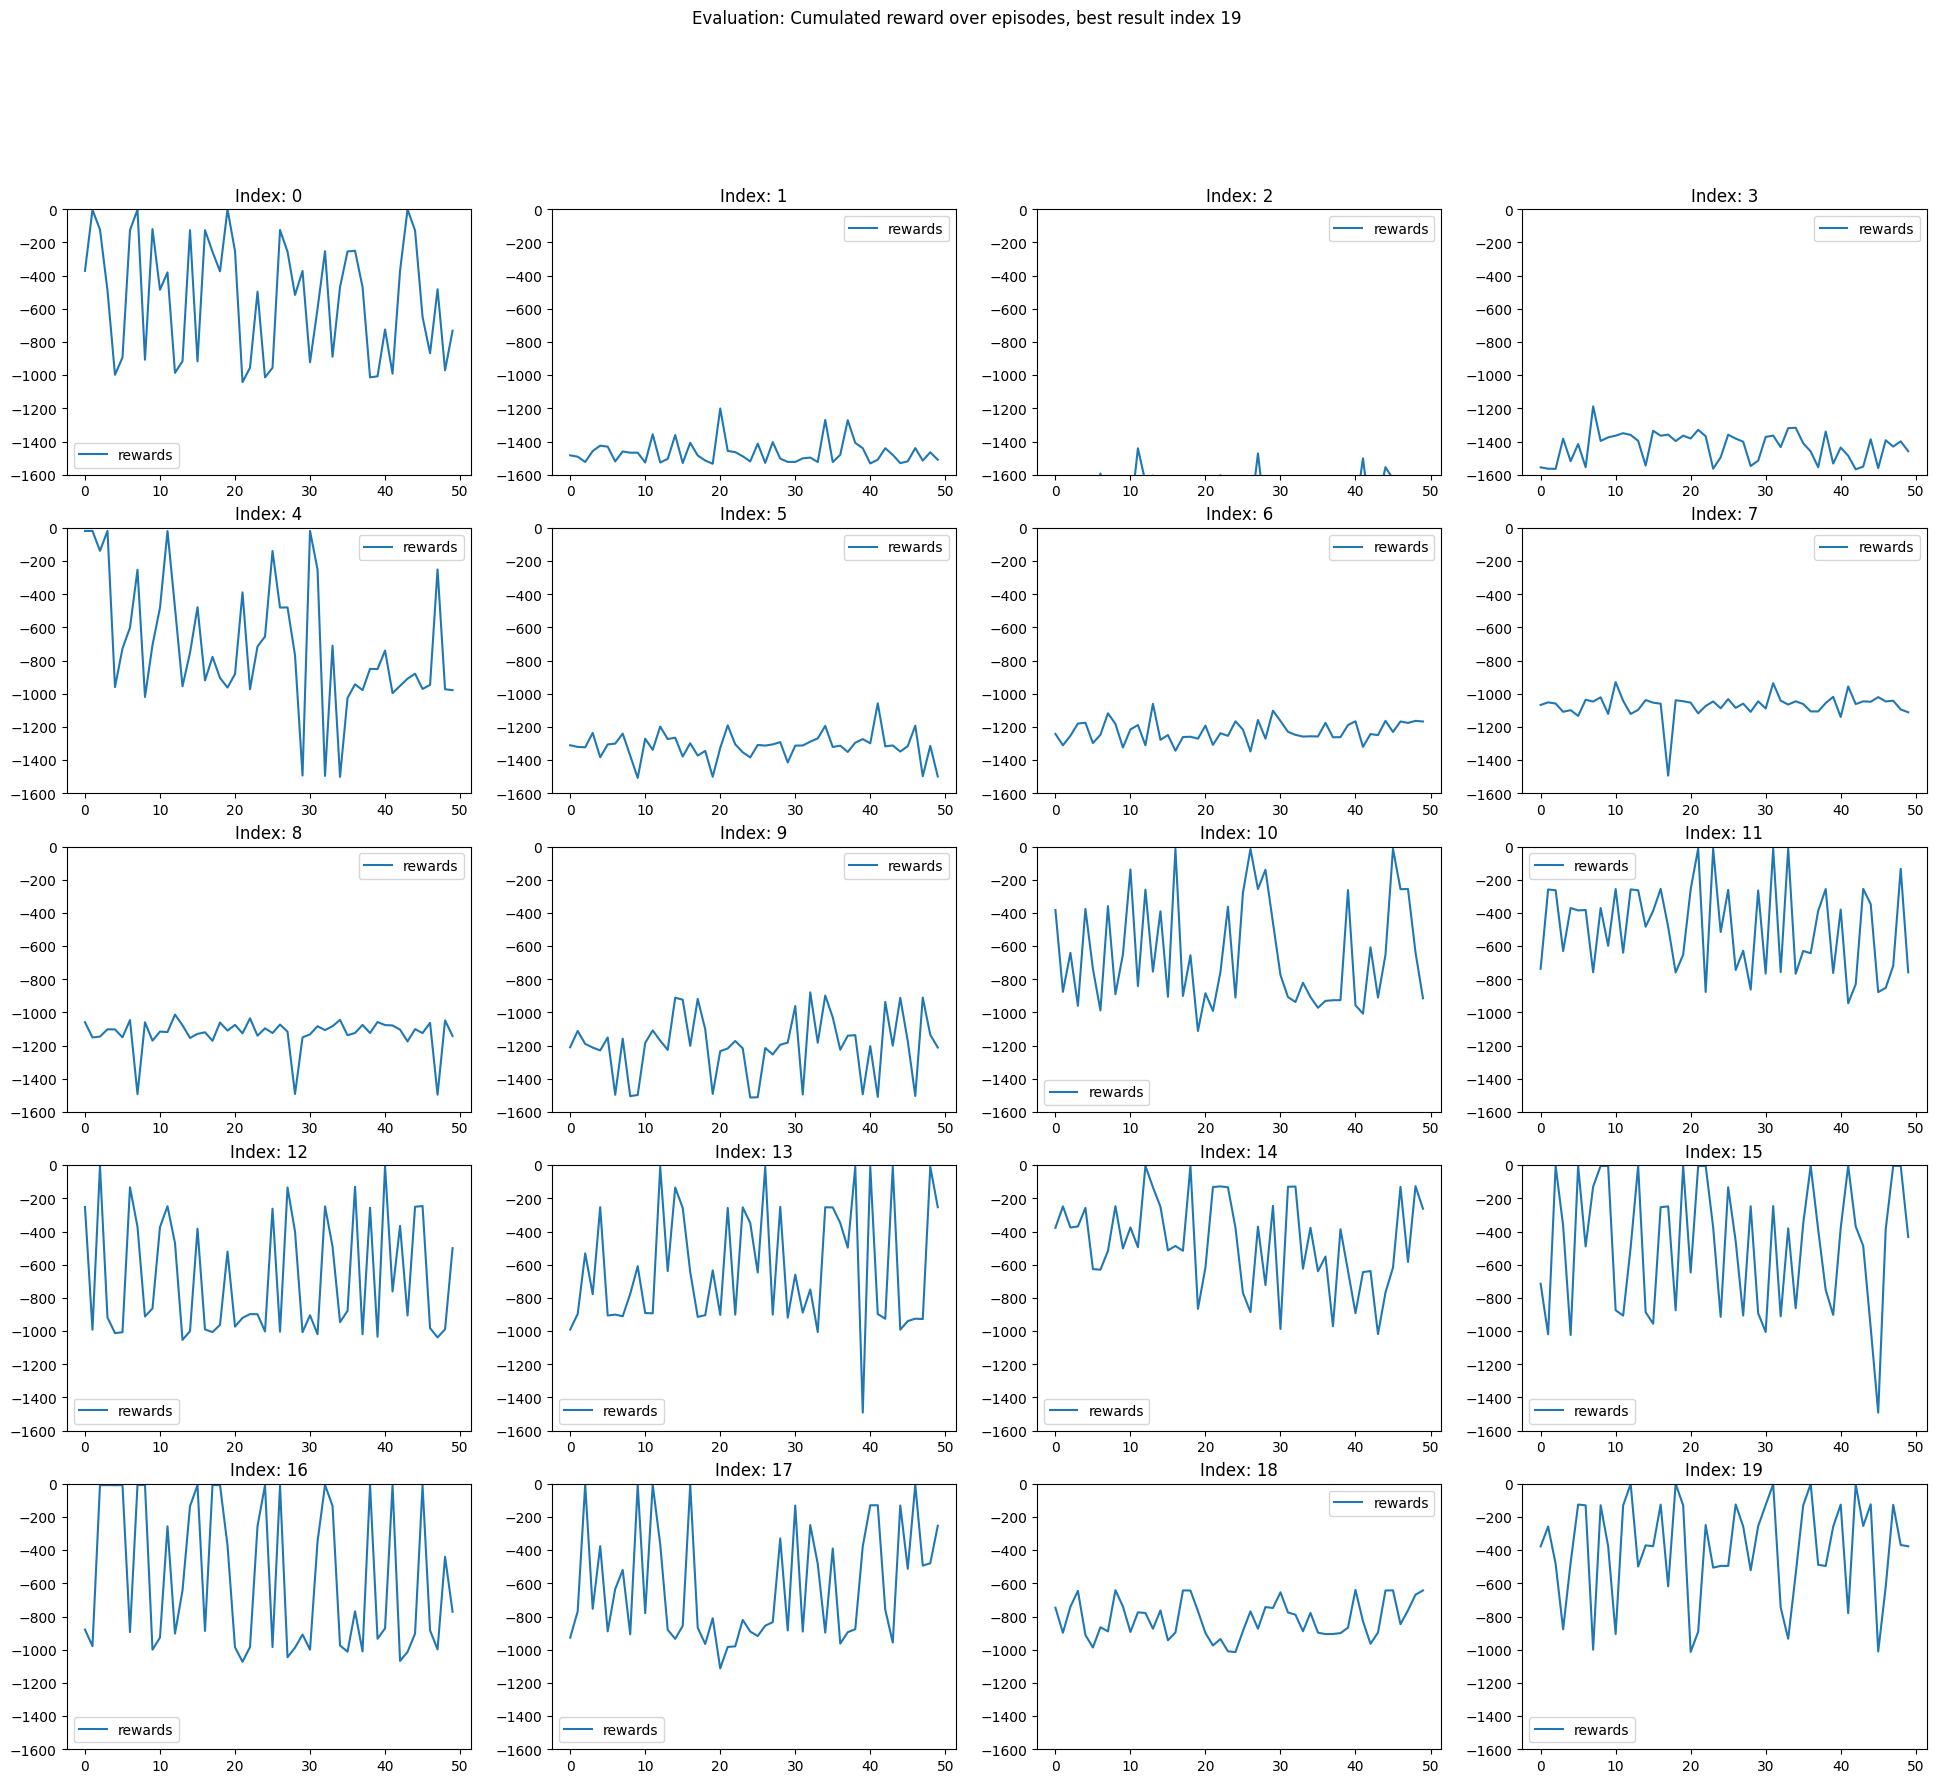

In [ ]:
evaluation_results = db['reinforce_trainable_mrp_max_deg3_norm_5000_evaluation']

rows = 5
cols = 4
window_size=5
fig, axes = plt.subplots(rows,cols)
axes = axes.flatten()
fig.set_figheight(20)
fig.set_figwidth(24)
fig.suptitle(f'Evaluation: Cumulated reward over episodes, best result index {best_index}')

for i in range(rows*cols):
    axes[i].plot(evaluation_results[i], label='rewards')
    axes[i].set_title(f'Index: {i}')
    axes[i].legend(loc='best')
    axes[i].set_ylim([-1600, 0])

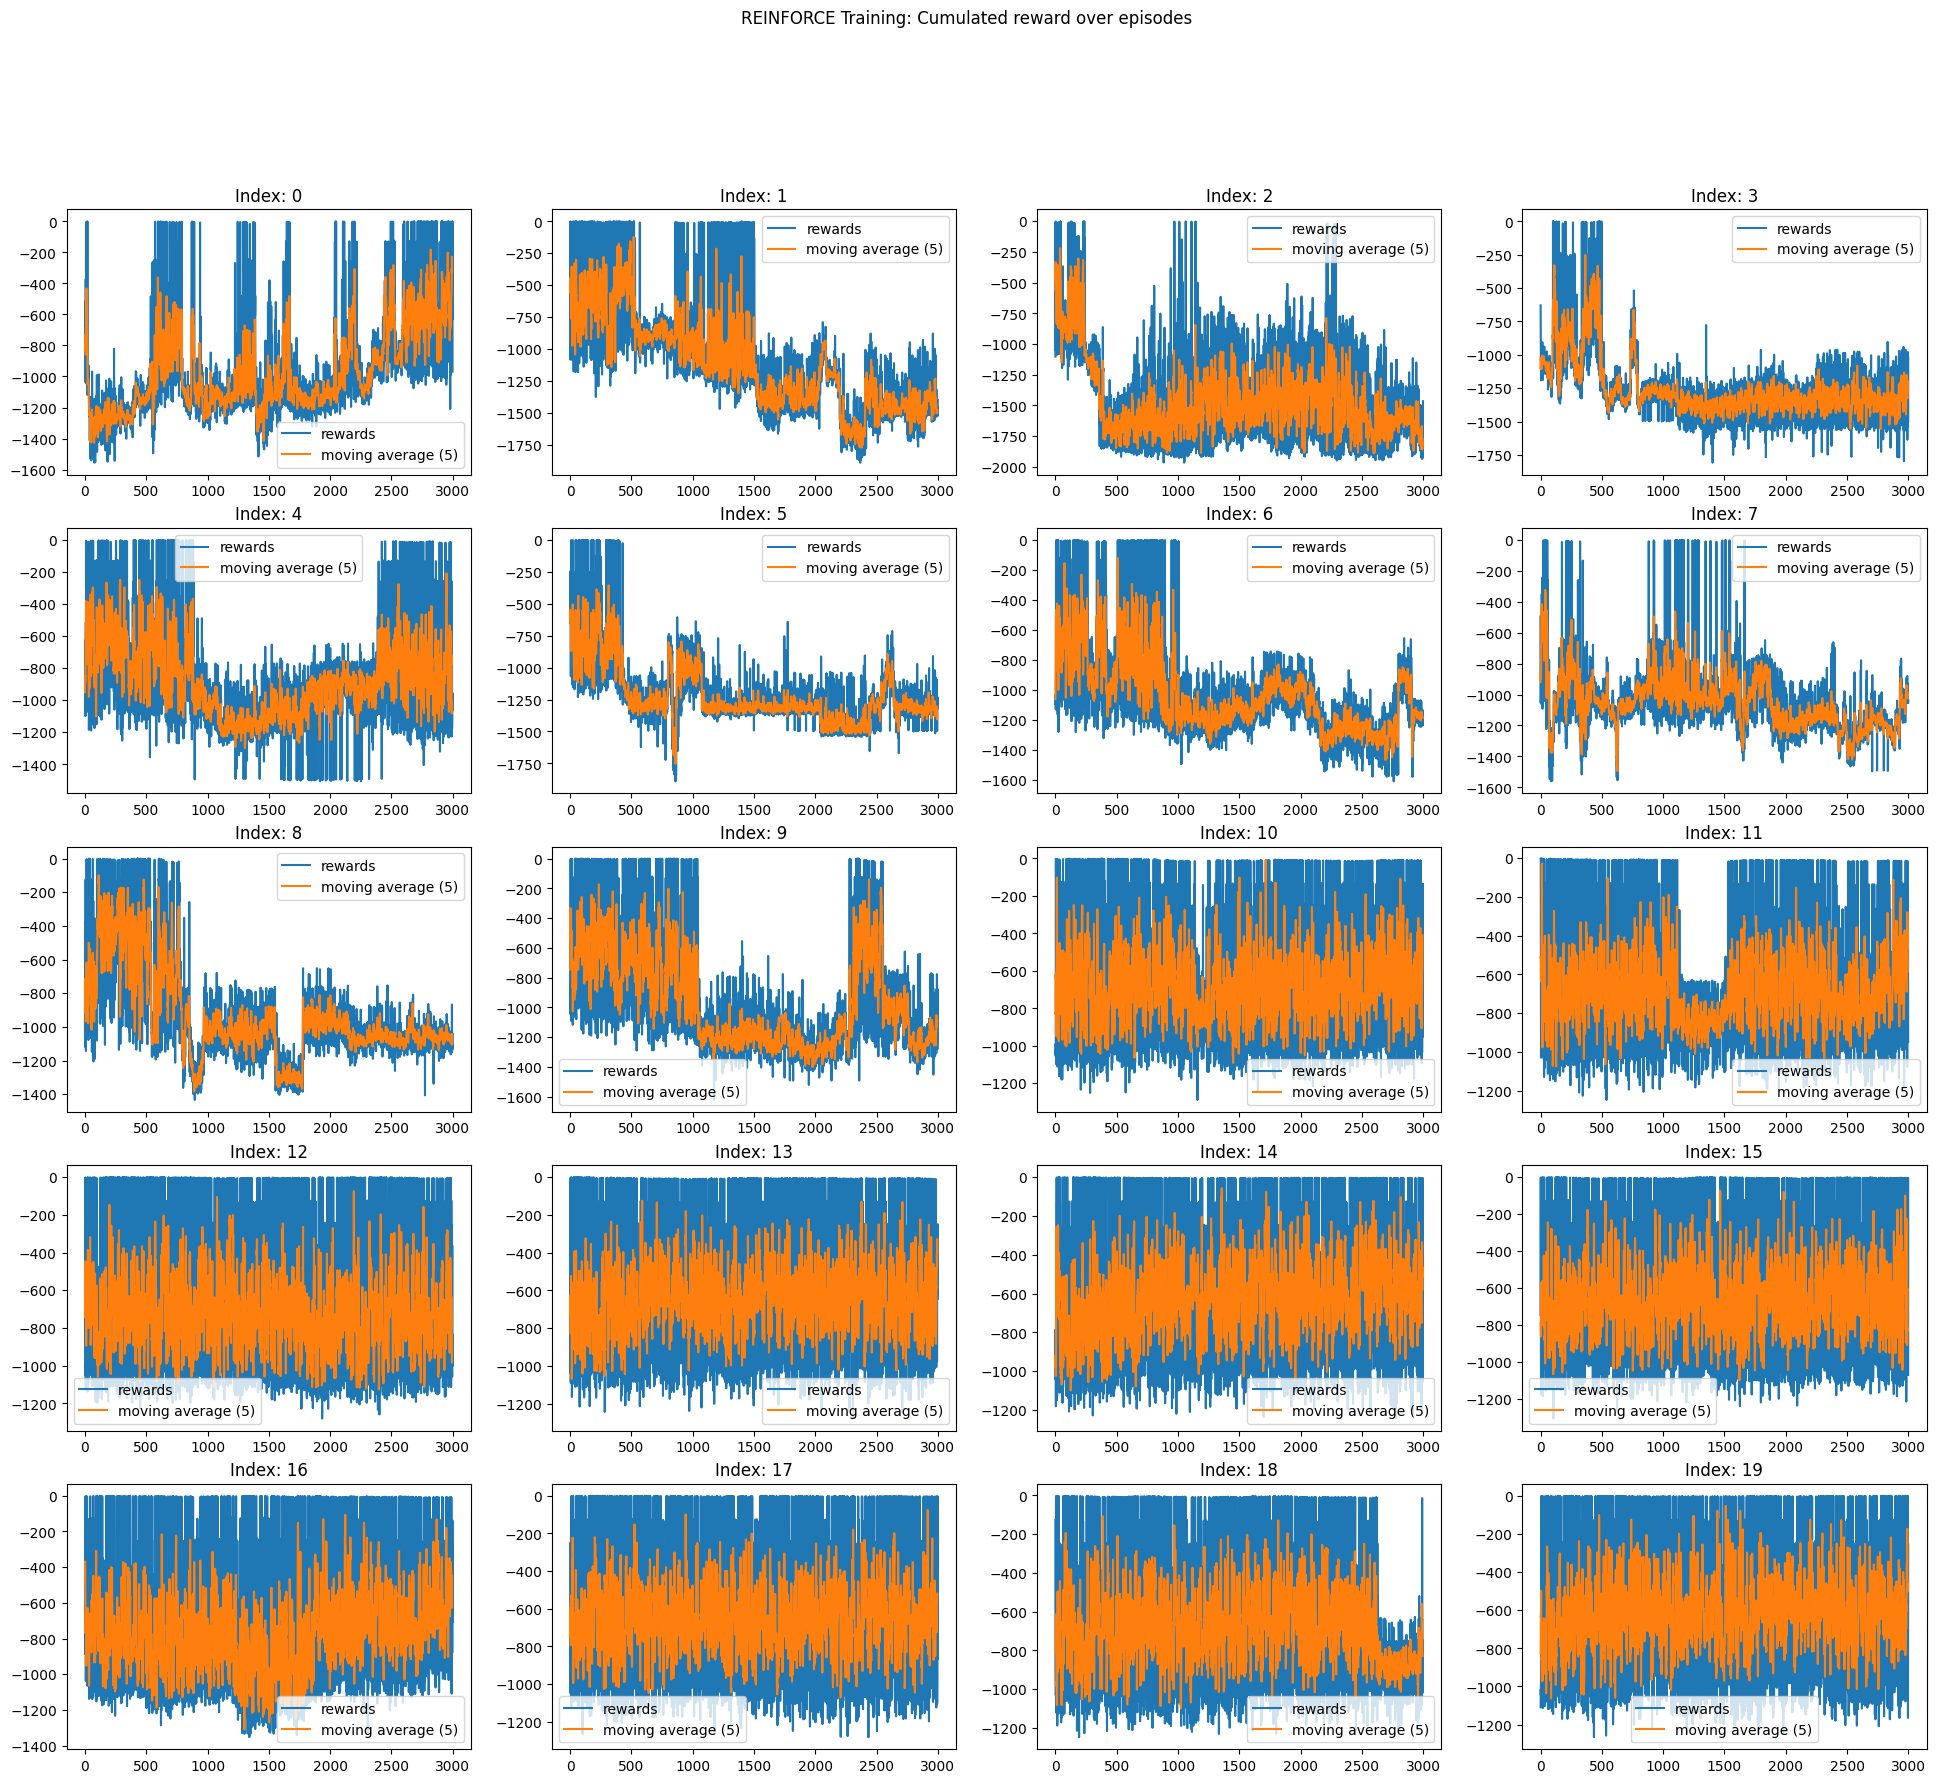

In [12]:
rows = 5
cols = 4
window_size=5
fig, axes = plt.subplots(rows,cols)
axes = axes.flatten()
fig.set_figheight(20)
fig.set_figwidth(24)
fig.suptitle(f'REINFORCE Training: Cumulated reward over episodes')

training_results = db['reinforce_trainable_mrp_max_deg3_norm_results_5000']

for i in range(rows*cols):
    moving_average_results = moving_average(training_results[i][1], window_size=window_size)
    axes[i].plot(training_results[i][1], label='rewards')
    axes[i].plot(moving_average_results, label=f'moving average ({window_size})')
    axes[i].set_title(f'Index: {i}')
    axes[i].legend(loc='best')

In [33]:
# gather single episode results of best policy
training_results = db['reinforce_trainable_mrp_max_deg3_norm_results_5000']
evaluation_results = db['reinforce_trainable_mrp_max_deg3_norm_5000_evaluation']
best_index = max(range(len(evaluation_results)), key=lambda i: np.mean(evaluation_results[i]))
db['pendulum_ch3_best_params'] = training_results[best_index][-1]

In [ ]:
r = []
for i in range(50):
    chebyshev_episode_reward, obs = run_chebyshev_model(training_results[best_index][-1], degree=3, start_loc=None, render=False)
    r.append(np.append(obs[0], chebyshev_episode_reward))

In [ ]:
# visualize best policy behaviour
training_results = db['reinforce_trainable_mrp_max_deg3_norm_results_5000']
evaluation_results = db['reinforce_trainable_mrp_max_deg3_norm_5000_evaluation']
best_index = max(range(len(evaluation_results)), key=lambda i: np.mean(evaluation_results[i]))

run_chebyshev_model(training_results[best_index][-1], degree=3, start_loc=[0.0, 1.0], render=False)

In [96]:
db['ch-3-5k-eval-obs'] = r

In [31]:
r = db['ch-3-5k-eval-obs']
r_tqc = db['tqc-eval-obs']

min_x = -1.0
min_y = -1.0
min_theta = -8.0
max_x = 1.0
max_y = 1.0
max_theta = 8.0

theta = []
theta_dot = []
reward = []

for o in r:
    theta.append(math.atan2(unnormalize(o[1], max_y, min_y), unnormalize(o[0], max_x, min_x)))
    theta_dot.append(unnormalize(o[2], max_theta, min_theta))
    reward.append(o[3])

theta_tqc = []
theta_dot_tqc = []
reward_tqc = []

for o in r_tqc:
    theta_tqc.append(math.atan2(o[1], o[0]))
    theta_dot_tqc.append(o[2])
    reward_tqc.append(o[3])

In [ ]:
r_tqc

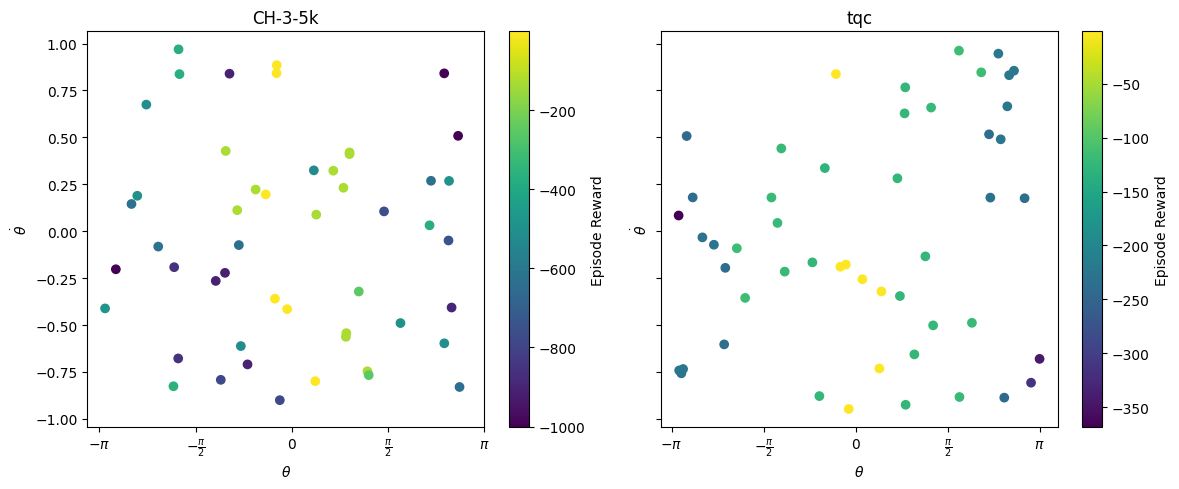

In [32]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

xticks = [-np.pi, -np.pi/2, 0, np.pi/2, np.pi]
xtick_labels = [r'$-\pi$', r'$-\frac{\pi}{2}$', r'$0$', r'$\frac{\pi}{2}$', r'$\pi$']

sc1 = ax1.scatter(theta, theta_dot, c=reward, cmap='viridis')
ax1.set_xticks(xticks)
ax1.set_xticklabels(xtick_labels)
ax1.set_title('CH-3-5k')
ax1.set_xlabel(r'$\theta$')
ax1.set_ylabel(r'$\dot{\theta}$')
fig.colorbar(sc1, ax=ax1, label='Episode Reward')

sc2 = ax2.scatter(theta_tqc, theta_dot_tqc, c=reward_tqc, cmap='viridis')
ax2.set_xticks(xticks)
ax2.set_xticklabels(xtick_labels)
ax2.set_title('tqc')
ax2.set_xlabel(r'$\theta$')
ax2.set_ylabel(r'$\dot{\theta}$')
fig.colorbar(sc2, ax=ax2, label='Episode Reward')

plt.tight_layout()
plt.show()



## Increasing degree

In [57]:
n_cpus = mp.cpu_count()
degree = 4
alpha_mu_1=0.003
alpha_sigma_1=0.0003
alpha_mu_2=0.0003
alpha_sigma_2=0.00003
episodes=3000
discount=0.9 
initial_sigma=0.25 

kwargs_1 = {'degree': degree, 'env_name': environment_name, 'alpha_mu': alpha_mu_1, 'alpha_sigma': alpha_sigma_1, 'episodes': episodes, 'discount': discount, 'initial_sigma': initial_sigma, 'method': 'reinforce', 'normalize_observations': True}
kwargs_2 = {'degree': degree, 'env_name': environment_name, 'alpha_mu': alpha_mu_2, 'alpha_sigma': alpha_sigma_2, 'episodes': episodes, 'discount': discount, 'initial_sigma': initial_sigma, 'method': 'reinforce', 'normalize_observations': True}

args = [copy.deepcopy(kwargs_1) for i in range(n_cpus//2)]
args.extend([copy.deepcopy(kwargs_2) for i in range(n_cpus//2)])

In [ ]:
with mp.Pool(processes=mp.cpu_count()) as pool:
    training_results = pool.map(parallel.job_reinforce_train, args)

# Permanently store results
db['reinforce_trainable_mrp_max_deg4_results_3000'] = training_results

/tmp/ipykernel_9174/928351899.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[i].legend(loc='best')


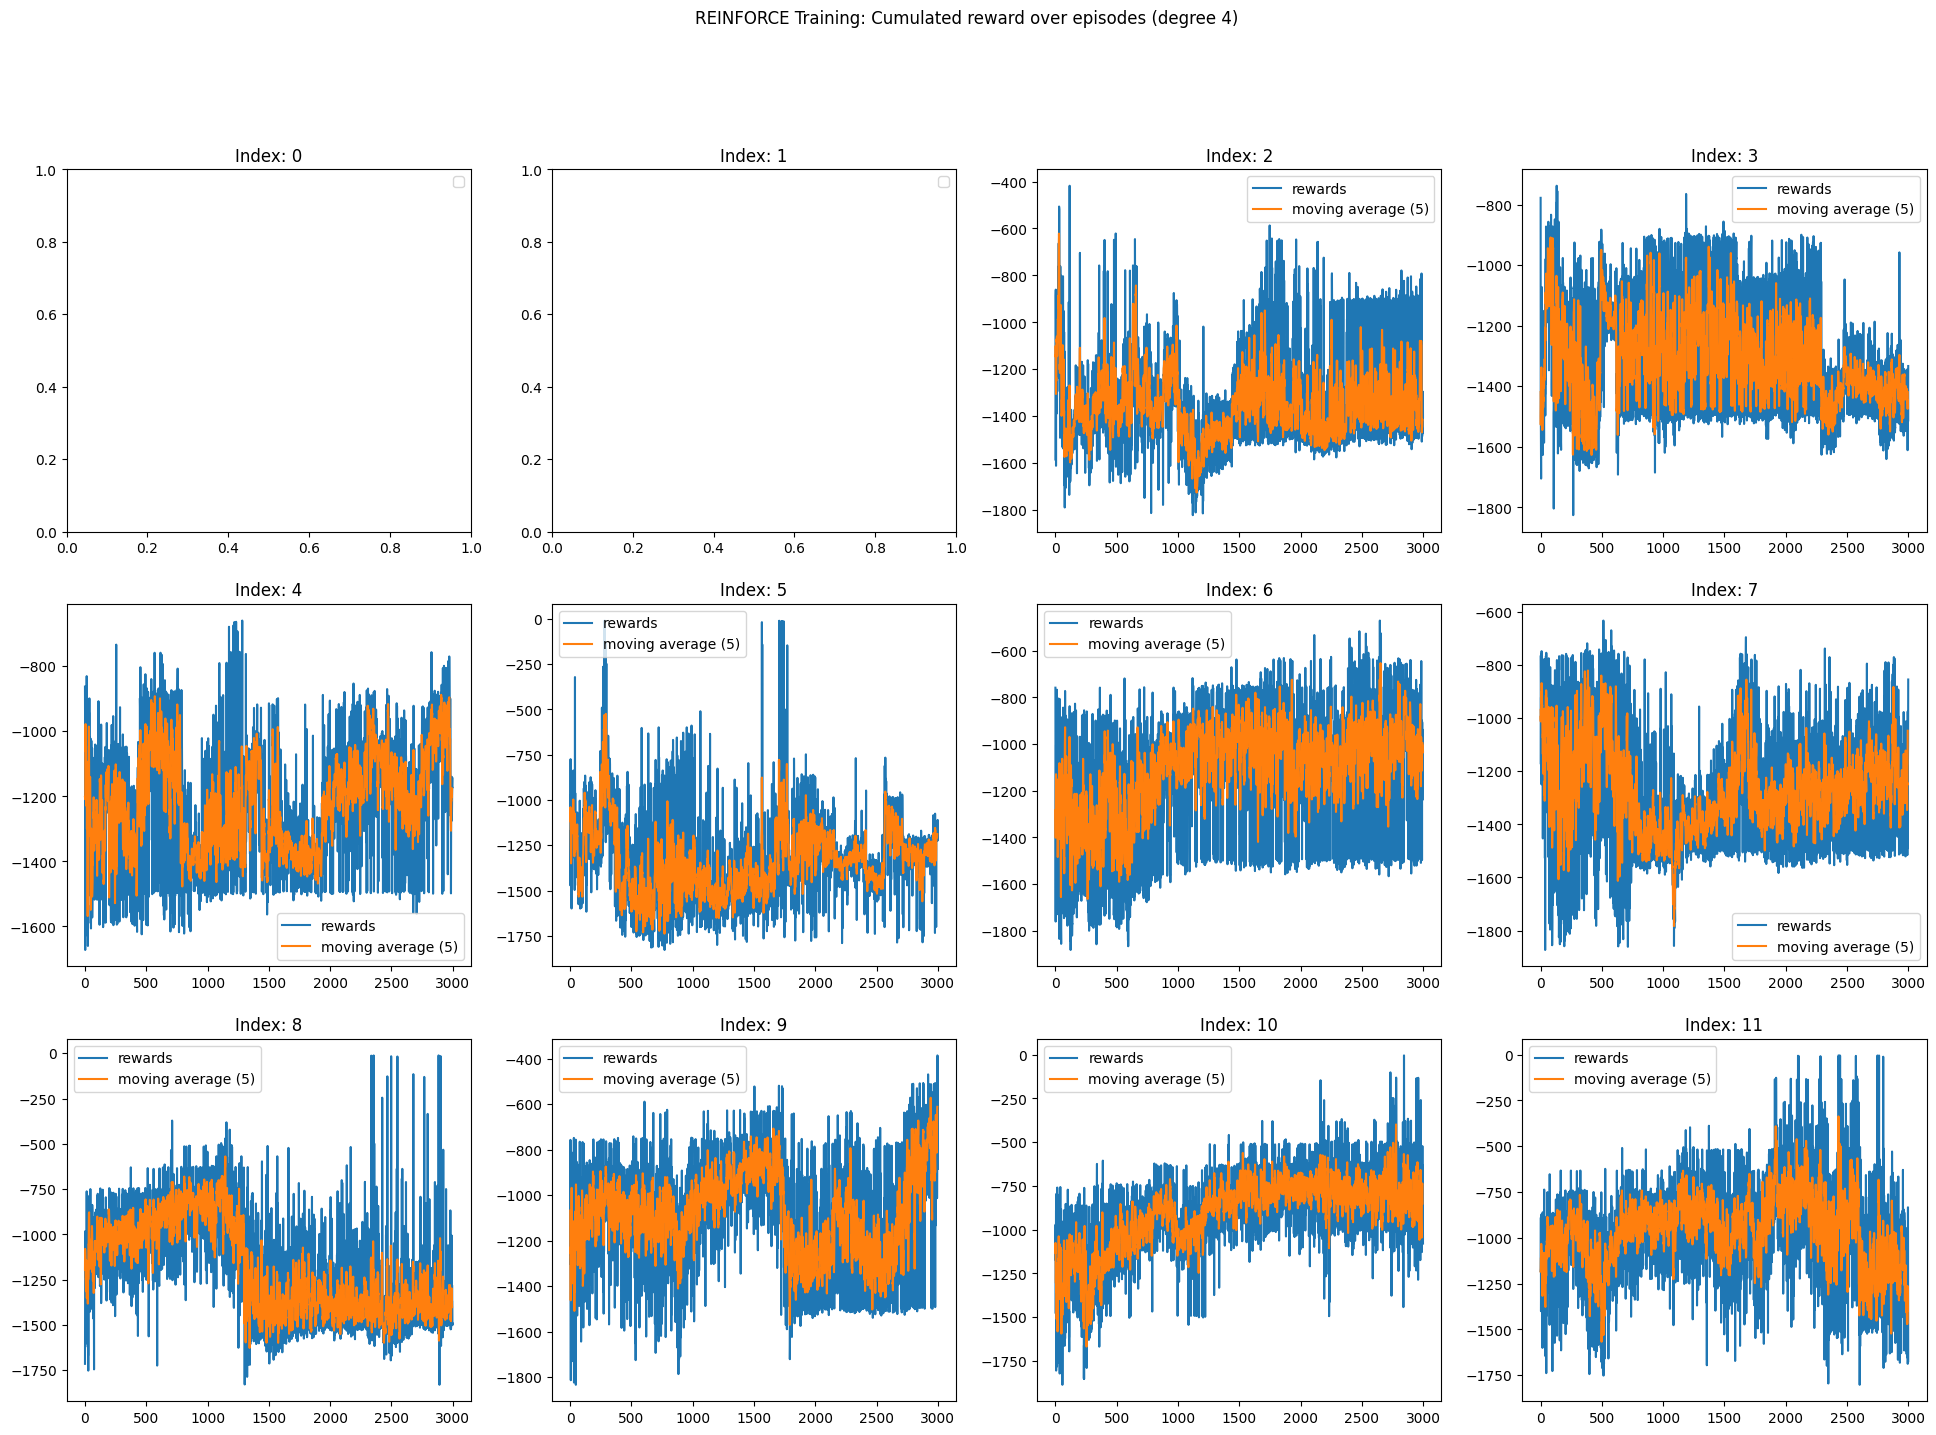

In [53]:
rows = 3
cols = 4
window_size=5
fig, axes = plt.subplots(rows,cols)
axes = axes.flatten()
fig.set_figheight(16)
fig.set_figwidth(24)
fig.suptitle(f'REINFORCE Training: Cumulated reward over episodes (degree 4)')

training_results = db['reinforce_trainable_mrp_max_deg4_results_3000']

for i in range(rows*cols):
    try:
        moving_average_results = moving_average(training_results[i][1], window_size=window_size)
        axes[i].plot(training_results[i][1], label='rewards')
        axes[i].plot(moving_average_results, label=f'moving average ({window_size})')
    except:
        pass
    axes[i].set_title(f'Index: {i}')
    axes[i].legend(loc='best')

In [ ]:
kwargs = {'env_name': environment_name, 'episodes': 50, 'degree': degree}
training_results = db['reinforce_trainable_mrp_max_deg4_results_3000']

n_runs = len(training_results)
args = []

for r in training_results:
    arg = copy.deepcopy(kwargs)
    try:
        arg['mu_coeffs'] = r[-1]
    except:
        arg['mu_coeffs'] = None
    args.append(arg)

with mp.Pool(processes=mp.cpu_count()) as pool:
    evaluation_results = pool.map(parallel.job_evaluate, args)

# Permanently store results
db['reinforce_trainable_mrp_max_deg4_norm_3000_evaluation'] = evaluation_results

In [59]:
evaluation_results = db['reinforce_trainable_mrp_max_deg4_norm_3000_evaluation']
best_index = max(range(len(evaluation_results)), key=lambda i: np.mean(evaluation_results[i]))
db['reinforce_trainable_mrp_max_deg4_norm_results_3000_best_eval_result'] = evaluation_results[best_index]

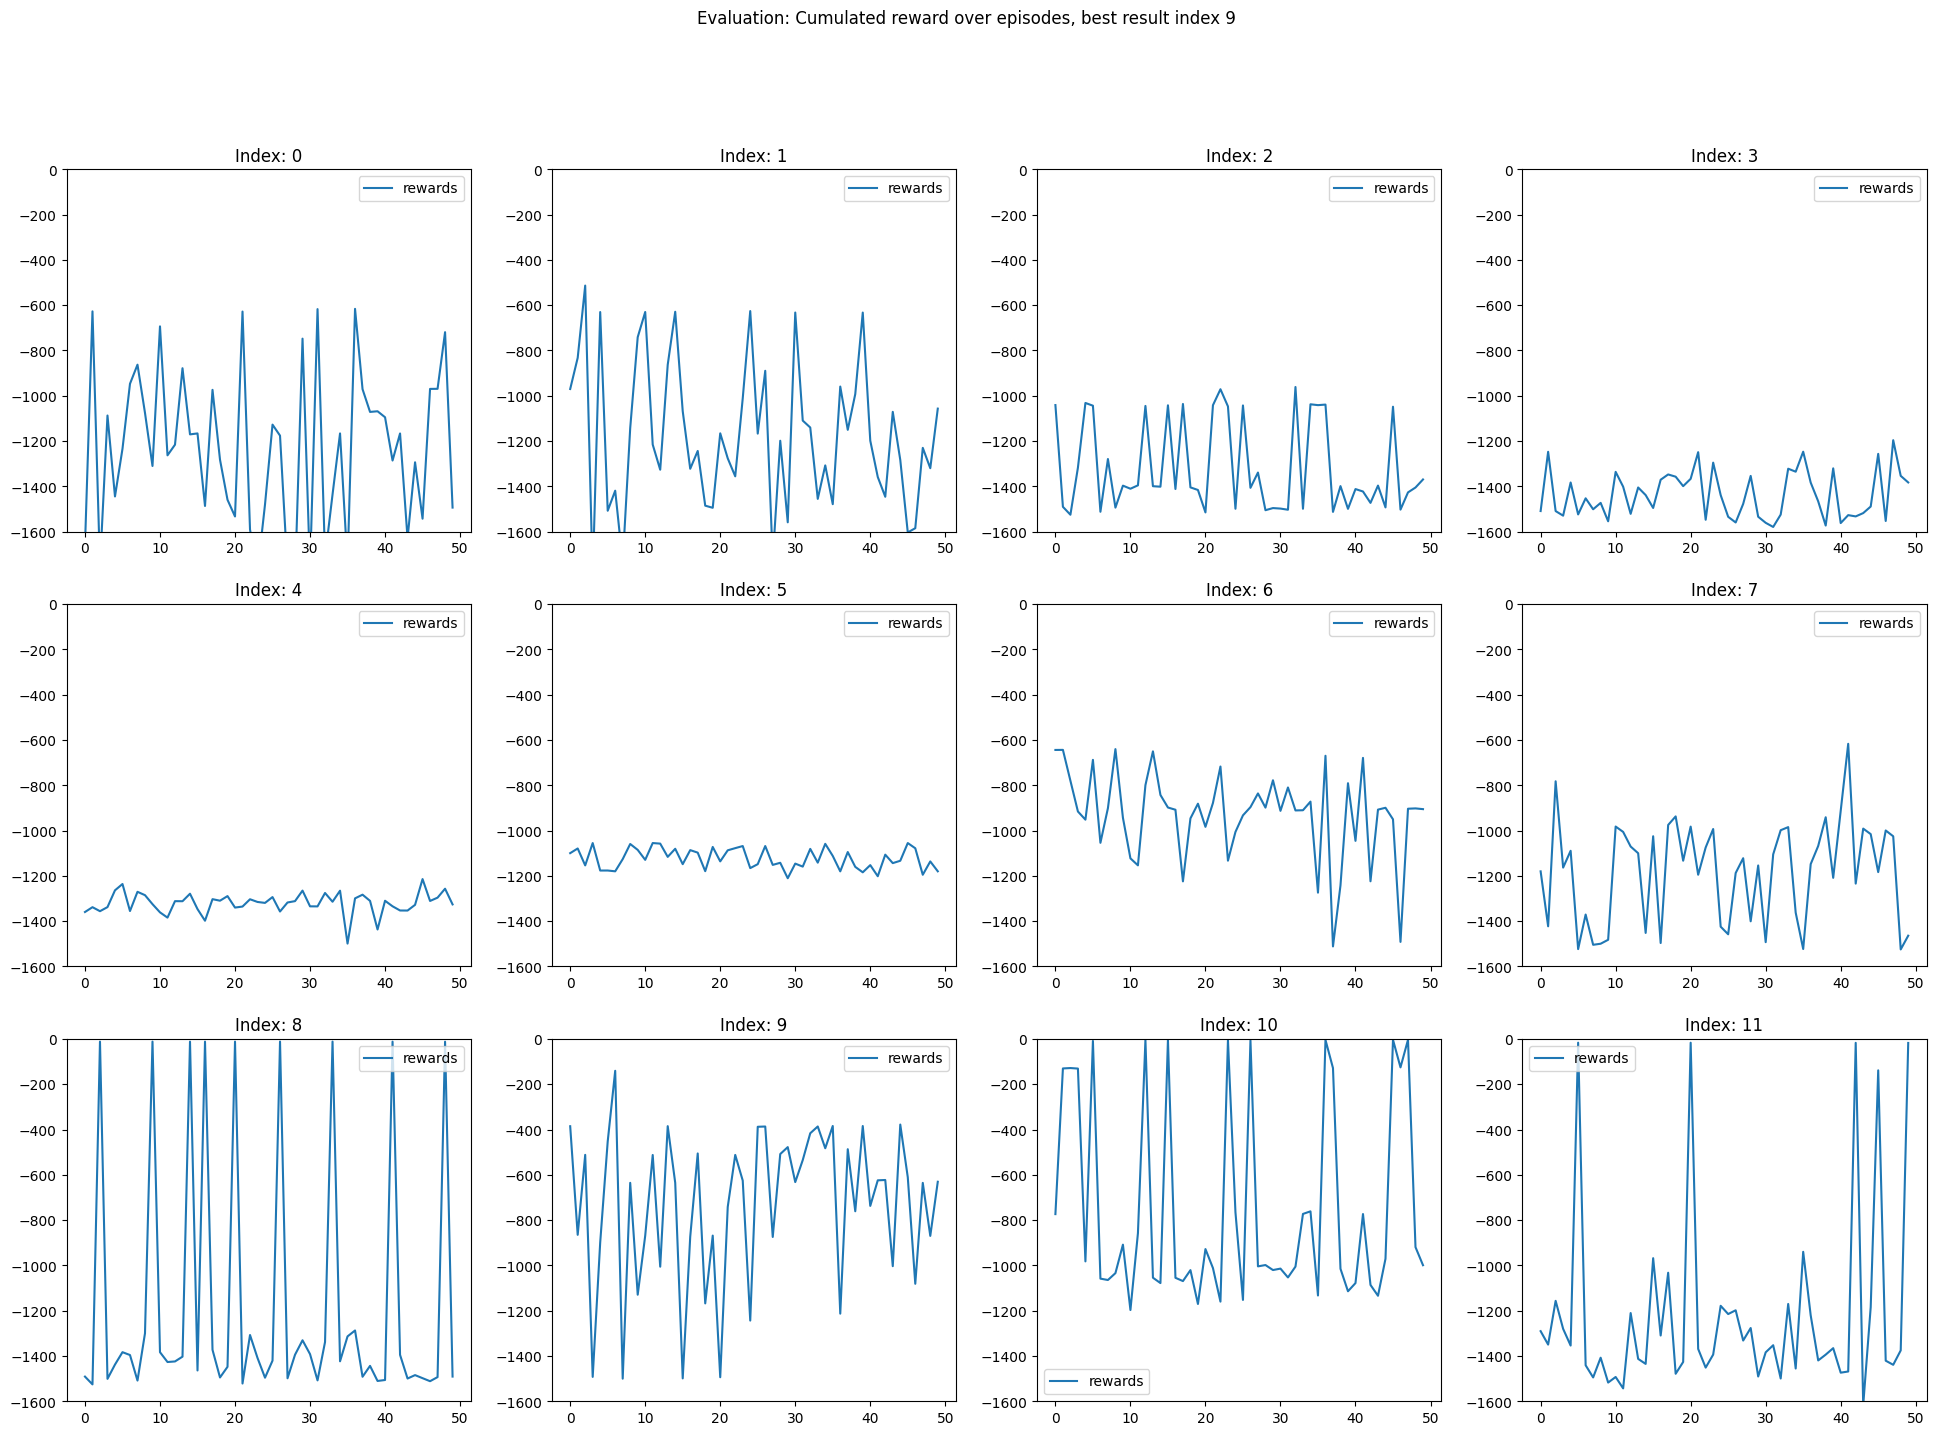

In [60]:
evaluation_results = db['reinforce_trainable_mrp_max_deg4_norm_3000_evaluation']

rows = 3
cols = 4
window_size=5
fig, axes = plt.subplots(rows,cols)
axes = axes.flatten()
fig.set_figheight(16)
fig.set_figwidth(24)
fig.suptitle(f'Evaluation: Cumulated reward over episodes, best result index {best_index}')

for i in range(rows*cols):
    axes[i].plot(evaluation_results[i], label='rewards')
    axes[i].set_title(f'Index: {i}')
    axes[i].legend(loc='best')
    axes[i].set_ylim([-1600, 0])

In [ ]:
# gather single episode results of best policy
training_results = db['reinforce_trainable_mrp_max_deg4_results_3000']
evaluation_results = db['reinforce_trainable_mrp_max_deg4_norm_3000_evaluation']
best_index = max(range(len(evaluation_results)), key=lambda i: np.mean(evaluation_results[i]))

r = []
for i in range(50):
    chebyshev_episode_reward, obs = run_chebyshev_model(training_results[best_index][-1], degree=4, start_loc=None, render=False)
    r.append(np.append(obs[0], chebyshev_episode_reward))

In [56]:
db['ch-4-3k-eval-obs'] = r

Worse performance than with degree 3

## Generate deterministic evaluation result

In [34]:
# Equidistant points for each dimension
n_points_per_dim = 50
angles = np.linspace(-np.pi, np.pi, n_points_per_dim)
velocities = np.linspace(-1, 1, n_points_per_dim)
angle_grid, velocity_grid = np.meshgrid(angles, velocities)
initial_states = np.column_stack([angle_grid.ravel(), velocity_grid.ravel()])

print(f"Total initial states: {len(initial_states)}") 
print(f"First few states:\n{initial_states[:5]}")

Total initial states: 2500
First few states:
[[-3.14159265 -1.        ]
 [-3.01336438 -1.        ]
 [-2.88513611 -1.        ]
 [-2.75690784 -1.        ]
 [-2.62867957 -1.        ]]


In [ ]:
eval_kwargs = {'env_name': 'DeterministicPendulum-v1', 'episodes': 1, 'normalize_observations': True, 'mu_coeffs': db['pendulum_ch3_best_params']}
rewards = []

all_eval_kwargs = []
for s in initial_states:
    args = copy.deepcopy(eval_kwargs)
    args['x_init'] = s[0]
    args['y_init'] = s[1]
    all_eval_kwargs.append(args)

with mp.Pool(mp.cpu_count()-1) as pool:
    rewards = pool.map(parallel.job_evaluate, all_eval_kwargs)

db['pendulum_ch3_eval_results'] = rewards
db['pendulum_ch3_eval_rewards'] = [np.mean(rewards), np.std(rewards), np.min(rewards), np.max(rewards)]

Generally, results with REINFORCE are unfavourable, see comparison in "Pendulum PPO" notebook.  